# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [21]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(2000)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
...,...,...,...,...,...,...,...
1102,"Helado bresler pote cassata 2,4l",Bresler,0,4359,5449,1090,congelados
1103,"Helado Trisabor chocolate lúcuma y manjar 2,4 L",Bresler,0,4359,5449,1090,congelados
1104,Shampoo Reconstrucción Completa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal
1105,Acondicionador Hidratación Intensa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal


In [25]:
df_com_desconto = df[df['Desconto'] > 0].copy()
df_com_desconto

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
989,Leche Trencito Chocolate 200ml,Nestlé,0,399,475,76,lacteos
990,Hamburguesa de vacuno 90 g,Super Beef,0,529,649,120,congelados
991,Hamburguesa vegana de garbanzos 100 g,Minuto Verde,0,719,849,130,congelados
992,Hamburguesa vegana de lentejas 100 g,Minuto Verde,0,719,849,130,congelados
993,Hamburguesa vegana de porotos 100 g,Minuto Verde,0,719,849,130,congelados
...,...,...,...,...,...,...,...
1102,"Helado bresler pote cassata 2,4l",Bresler,0,4359,5449,1090,congelados
1103,"Helado Trisabor chocolate lúcuma y manjar 2,4 L",Bresler,0,4359,5449,1090,congelados
1104,Shampoo Reconstrucción Completa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal
1105,Acondicionador Hidratación Intensa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [3]:
#Seu código aqui para a média
media_geral = df.groupby("Categoria")["Preco_Normal"].mean()
media_geral

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1783.556485
comidas-preparadas,3095.043478
congelados,2108.042553
frutas,1724.473684
instantaneos-y-sopas,765.491228
lacteos,2385.219239
verduras,1343.296875


In [4]:
#Seu código aqui para a mediana
mediana_geral = df.groupby("Categoria")["Preco_Normal"].median()
mediana_geral

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1569.0
comidas-preparadas,3290.0
congelados,1519.0
frutas,1195.0
instantaneos-y-sopas,439.0
lacteos,989.0
verduras,1180.0


Digite aqui as categorias: Beleza e cuidado pessoal, comidas preparadas, congelados, frutas, instantaneos e sopas, lacteos e verduras.



# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [11]:
#Seu código aqui
desvio_padrao = df.groupby("Categoria")["Preco_Normal"].std().sort_values(ascending=False)
desvio_padrao

,Preco_Normal
Categoria,
lacteos,3925.816164
belleza-y-cuidado-personal,2210.041719
congelados,2111.539896
comidas-preparadas,2019.911428
frutas,1639.151114
instantaneos-y-sopas,1170.232869
verduras,1012.699625


Quanto maior o desvio padrão, maior é a diferença entre a média e a mediana. Um exemplo são os produtos lácteos, que foram os que mais destoaram entre a média e a mediana, indicando que essa categoria contém outliers que 'puxam' a média para cima.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

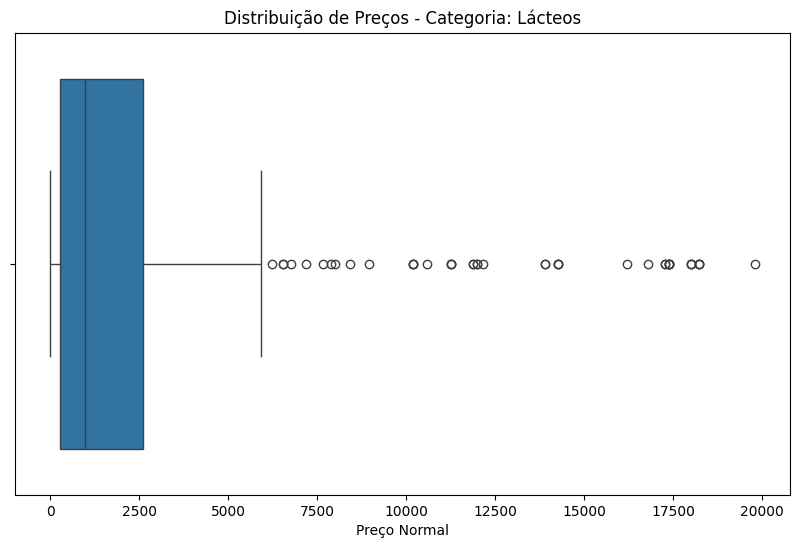

In [15]:
#Seu código aqui
dados_categoria = df.loc[df['Categoria'] == 'lacteos']
plt.figure(figsize=(10,6))
sns.boxplot(x=dados_categoria['Preco_Normal'])
plt.title('Distribuição de Preços - Categoria: Lácteos')
plt.xlabel('Preço Normal')
plt.show()

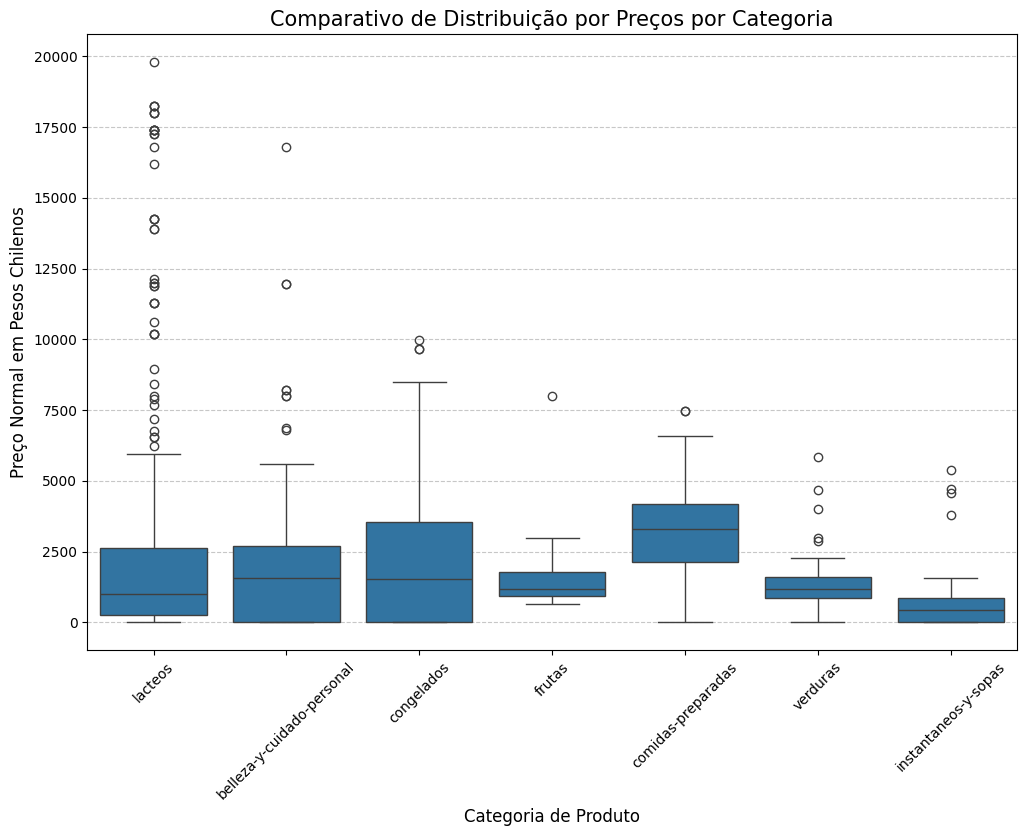

In [16]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Categoria', y='Preco_Normal', data=df)
plt.title('Comparativo de Distribuição por Preços por Categoria', fontsize= 15)
plt.xlabel('Categoria de Produto', fontsize=12)
plt.ylabel('Preço Normal em Pesos Chilenos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle= '--', alpha= 0.7)

plt.show()

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

In [27]:
# Seu código aqui
media_descontos = df_com_desconto.groupby('Categoria')['Desconto'].mean().sort_values()
media_descontos



,Desconto
Categoria,
comidas-preparadas,500.000000
congelados,603.283333
belleza-y-cuidado-personal,684.116279
lacteos,707.545455


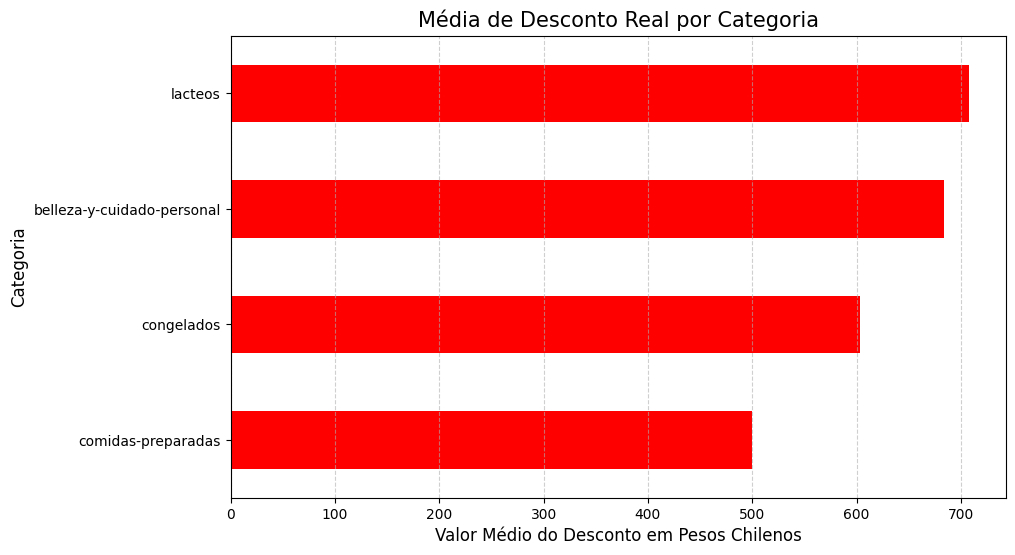

In [31]:
plt.figure(figsize=(10,6))
media_descontos.plot(kind='barh', color= 'red')
plt.title('Média de Desconto Real por Categoria', fontsize= 15)
plt.xlabel('Valor Médio do Desconto em Pesos Chilenos', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha= 0.6)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [34]:
# Seu código aqui
df_agrupado = df_com_desconto.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

fig = px.treemap(df_agrupado,
                 path =['Categoria', 'Marca'],
                 values='Desconto',
                 title='Mapa Interativo: Média de Desconto por Categora e Marca',
                 color='Desconto',
                 color_continuous_scale= 'RdBu')
fig.show()